In [1]:
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from itertools import product

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import acf, pacf
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

from xgboost import XGBRegressor
from xgboost import plot_importance
from xgboost.callback import EarlyStopping
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')

In [2]:
data_path = './data/'
sales_train = pd.read_csv(data_path + 'sales_train.csv')
shops = pd.read_csv(data_path + 'shops.csv')
items = pd.read_csv(data_path + 'items.csv')
item_categories = pd.read_csv(data_path + 'item_categories.csv')
test = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')

### Data insights, cleaning and feature engineering (Part 1)

Now that we have the datasets loaded, we will perform following tasks
* Data cleaning
* Some basic feature engineering
* Data observation

Some of these tasks are interdependent, i.e, they will be carried out together, such as: based on the observations, data will get cleaned, or new features will be added or modified.

In [3]:
def compress(df, verbose = True):
    start = df.memory_usage().sum() / 1024 ** 2
    for col in df.columns:
        dtype_name = df[col].dtype.name
        if dtype_name == 'object':
            pass
        elif dtype_name == 'bool':
            df[col] = df[col].astype('int8')
        elif dtype_name.startswith('int') or (df[col].round() == df[col]).all():
            df[col] = pd.to_numeric(df[col], downcast = 'integer')
        else:
            df[col] = pd.to_numeric(df[col], downcast = 'float')
    end = df.memory_usage().sum() / 1024 ** 2
    compressed_per = (100 * (start - end) / start)
    if verbose:
        print("{:.1f}% compressed".format(100 * (start - end) / start))

    return df

In [4]:
dfs = [sales_train, shops, items, item_categories, test]
for df in dfs:
    
    df = compress(df)

54.2% compressed
38.5% compressed
54.2% compressed
39.8% compressed
70.8% compressed


In [5]:
test.head()

,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


In [6]:
sales_train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day
0,02.01.2013,0,59,22154,999.00,1
1,03.01.2013,0,25,2552,899.00,1
2,05.01.2013,0,25,2552,899.00,-1
3,06.01.2013,0,25,2554,1709.05,1
4,15.01.2013,0,25,2555,1099.00,1


In [7]:
sales_train.info(show_counts = True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 6 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   date            2935849 non-null  object 
 1   date_block_num  2935849 non-null  int8   
 2   shop_id         2935849 non-null  int8   
 3   item_id         2935849 non-null  int16  
 4   item_price      2935849 non-null  float64
 5   item_cnt_day    2935849 non-null  int16  
dtypes: float64(1), int16(2), int8(2), object(1)
memory usage: 61.6+ MB


### Sales Data Observations
* There are no null records
* The training dataset has data from Jan 2013 till Oct 2015 in chronological order. We can keep aside data for Sept and Oct 2015 for testing, apart from the actual test dataset given. 
* `date_block_num` features is a month representation of the sale starting from 0 representing Jan 2013 and Oct 2015 is represented by 33.
* Each record in the dataset represents number of items sold by one shop on a given day. Since the goal is to forecast monthly sales, we can aggregate the number of items sold by each shop for each month. This sum along with the `item_price` can be used to calculate the total sale for each shop in each month.
* With this aggregation we can drop the date feature and use only the `date_block_num` feature.
* `item_price` is for each item even though it is part of the `sales_train` dataframe. So total sale on a given date by a given shop for a given item is `item_price * item_cnt_day`.

In [8]:
shops.head()

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
2,"Адыгея ТЦ ""Мега""",2
3,"Балашиха ТРК ""Октябрь-Киномир""",3
4,"Волжский ТЦ ""Волга Молл""",4


In [9]:
shops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   shop_name  60 non-null     object
 1   shop_id    60 non-null     int8  
dtypes: int8(1), object(1)
memory usage: 672.0+ bytes


### Shops observations
* Based on translations of the `shop_name` data for some samples, it looks like the first token in the name (separated by space) is the name of the city in which the shop is located.
* We can extract the city name from this and add a new feature in the shop dataset

Based on the shop names there are 4 pairs of shops where the name is slightly different (just one character changed). Assuming it is a typo we can merge these records. 

In [10]:
shops.loc[shops['shop_id'].isin([0, 57, 1, 58, 10, 11, 39, 40])]

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
10,Жуковский ул. Чкалова 39м?,10
11,Жуковский ул. Чкалова 39м²,11
39,"РостовНаДону ТРК ""Мегацентр Горизонт""",39
40,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной",40
57,"Якутск Орджоникидзе, 56",57
58,"Якутск ТЦ ""Центральный""",58


In [11]:
shops.loc[shops['shop_id'] == 57, 'shop_name'] = '!Якутск Орджоникидзе, 56 фран'
shops.loc[shops['shop_id'] == 58, 'shop_name'] = '!Якутск ТЦ "Центральный" фран'
shops.loc[shops['shop_id'] == 11, 'shop_name'] = 'Жуковский ул. Чкалова 39м?'
shops.loc[shops['shop_id'] == 39, 'shop_name'] = 'РостовНаДону ТРК "Мегацентр Горизонт" Островной'
shop_ids_to_delete = [57, 58, 11, 39]
shops = shops[~shops['shop_id'].isin(shop_ids_to_delete)]



In [12]:
shops.loc[shops['shop_id'].isin([0, 57, 1, 58, 10, 11, 39, 40])]

,shop_name,shop_id
0,"!Якутск Орджоникидзе, 56 фран",0
1,"!Якутск ТЦ ""Центральный"" фран",1
10,Жуковский ул. Чкалова 39м?,10
40,"РостовНаДону ТРК ""Мегацентр Горизонт"" Островной",40


In [13]:
shops['city'] = shops['shop_name'].apply(lambda x: x.split()[0])

In [14]:
shops['city'].unique()

array(['!Якутск', 'Адыгея', 'Балашиха', 'Волжский', 'Вологда', 'Воронеж',
       'Выездная', 'Жуковский', 'Интернет-магазин', 'Казань', 'Калуга',
       'Коломна', 'Красноярск', 'Курск', 'Москва', 'Мытищи', 'Н.Новгород',
       'Новосибирск', 'Омск', 'РостовНаДону', 'СПб', 'Самара', 'Сергиев',
       'Сургут', 'Томск', 'Тюмень', 'Уфа', 'Химки', 'Цифровой', 'Чехов',
       'Ярославль'], dtype=object)

In [15]:
shops.head()

,shop_name,shop_id,city
0,"!Якутск Орджоникидзе, 56 фран",0,!Якутск
1,"!Якутск ТЦ ""Центральный"" фран",1,!Якутск
2,"Адыгея ТЦ ""Мега""",2,Адыгея
3,"Балашиха ТРК ""Октябрь-Киномир""",3,Балашиха
4,"Волжский ТЦ ""Волга Молл""",4,Волжский


In [16]:
# Now change the shop_ids of the records related to the deleted duplicate shops. 

sales_train.loc[sales_train['shop_id'] == 57, 'shop_id'] = 0
sales_train.loc[sales_train['shop_id'] == 58, 'shop_id'] = 1
sales_train.loc[sales_train['shop_id'] == 11, 'shop_id'] = 10
sales_train.loc[sales_train['shop_id'] == 39, 'shop_id'] = 40

In [17]:
# We need to do the same operation in the test data as well
test.loc[test['shop_id'] == 57, 'shop_id'] = 0
test.loc[test['shop_id'] == 58, 'shop_id'] = 1
test.loc[test['shop_id'] == 11, 'shop_id'] = 10
test.loc[test['shop_id'] == 39, 'shop_id'] = 40

In [18]:
items.head()

,item_name,item_id,item_category_id
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40
1,!ABBYY FineReader 12 Professional Edition Full...,1,76
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40
4,***КОРОБКА (СТЕКЛО) D,4,40


In [19]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22170 entries, 0 to 22169
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   item_name         22170 non-null  object
 1   item_id           22170 non-null  int16 
 2   item_category_id  22170 non-null  int8  
dtypes: int16(1), int8(1), object(1)
memory usage: 238.3+ KB


In [20]:
items['first_sold_month'] = sales_train.groupby('item_id').agg({'date_block_num': 'min'})['date_block_num']

items.head()

,item_name,item_id,item_category_id,first_sold_month
0,! ВО ВЛАСТИ НАВАЖДЕНИЯ (ПЛАСТ.) D,0,40,20.0
1,!ABBYY FineReader 12 Professional Edition Full...,1,76,15.0
2,***В ЛУЧАХ СЛАВЫ (UNV) D,2,40,19.0
3,***ГОЛУБАЯ ВОЛНА (Univ) D,3,40,18.0
4,***КОРОБКА (СТЕКЛО) D,4,40,20.0


In [21]:
# There are many items that are not yet sold ( for the period of the training data). We can assume that for those items the first month old can be 34 ( month number for m the testing data.

items['first_sold_month'] = items['first_sold_month'].fillna(34)

In [22]:
item_categories.head()

,item_category_name,item_category_id
0,PC - Гарнитуры/Наушники,0
1,Аксессуары - PS2,1
2,Аксессуары - PS3,2
3,Аксессуары - PS4,3
4,Аксессуары - PSP,4


In [23]:
item_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   item_category_name  84 non-null     object
 1   item_category_id    84 non-null     int8  
dtypes: int8(1), object(1)
memory usage: 888.0+ bytes


### Observations about item Categories
* Based on the translation of the item category names, it looks like the first word (before a space) represents a category type, such as Books, Games, Accessories, etc. These category types have subcategories.

In [24]:
item_categories['category_type'] = item_categories['item_category_name'].apply(lambda x: x.split()[0])
item_categories['category_type'].value_counts()

category_type
Игры          14
Книги         13
Подарки       12
Игровые        8
Аксессуары     7
Музыка         6
Программы      6
Карты          5
Кино           5
Служебные      2
Чистые         2
PC             1
Билеты         1
Доставка       1
Элементы       1
Name: count, dtype: int64

* Though there are about 15 category types, some of them have very few subcategories. Therefore, we can merge such category types into a single type and call it "Разное" (Russian for "misc.")


In [25]:
def merge_category_type(x):
    if len(item_categories[item_categories['category_type'] == x]) >= 5:
        return x
    else:
        return 'Разное'

item_categories['category_type'] = item_categories['category_type'].apply(merge_category_type)
item_categories.head()

,item_category_name,item_category_id,category_type
0,PC - Гарнитуры/Наушники,0,Разное
1,Аксессуары - PS2,1,Аксессуары
2,Аксессуары - PS3,2,Аксессуары
3,Аксессуары - PS4,3,Аксессуары
4,Аксессуары - PSP,4,Аксессуары


### Item, Categories and Shops Observations
* None of the datasets for shops, items and item categories have null records.
* There are 22170 items (we need to verify for uniqueness) across 84 categories, sold in 60 shops.
* Sales data is connected with items and shops using `item_id` and `shop_id`, whereas item is connected with its category using `item_category_id` in the items dataset.
* We can merge these three datasets with the sales dataset and retain only the id features from shop, item and item_category datasets.

We can derive total sale amount by each shop per item from `item_price` and `item_cnt_day`

In [26]:
sales_train['sale_amount'] = sales_train['item_price'] * sales_train['item_cnt_day']

In [27]:
sales_train.tail()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,sale_amount
2935844,10.10.2015,33,25,7409,299.0,1,299.0
2935845,09.10.2015,33,25,7460,299.0,1,299.0
2935846,14.10.2015,33,25,7459,349.0,1,349.0
2935847,22.10.2015,33,25,7440,299.0,1,299.0
2935848,03.10.2015,33,25,7460,299.0,1,299.0


### Now merge dataframes in to sales dataframe

In [28]:
train = sales_train.merge(shops, on = 'shop_id', how = 'left')
train = train.merge(items, on = 'item_id', how = 'left')
train = train.merge(item_categories, on = 'item_category_id', how = 'left')

In [29]:
train.head()

,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,sale_amount,shop_name,city,item_name,item_category_id,first_sold_month,item_category_name,category_type
0,02.01.2013,0,59,22154,999.00,1,999.00,"Ярославль ТЦ ""Альтаир""",Ярославль,ЯВЛЕНИЕ 2012 (BD),37,0.0,Кино - Blu-Ray,Кино
1,03.01.2013,0,25,2552,899.00,1,899.00,"Москва ТРК ""Атриум""",Москва,DEEP PURPLE The House Of Blue Light LP,58,0.0,Музыка - Винил,Музыка
2,05.01.2013,0,25,2552,899.00,-1,-899.00,"Москва ТРК ""Атриум""",Москва,DEEP PURPLE The House Of Blue Light LP,58,0.0,Музыка - Винил,Музыка
3,06.01.2013,0,25,2554,1709.05,1,1709.05,"Москва ТРК ""Атриум""",Москва,DEEP PURPLE Who Do You Think We Are LP,58,0.0,Музыка - Винил,Музыка
4,15.01.2013,0,25,2555,1099.00,1,1099.00,"Москва ТРК ""Атриум""",Москва,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,0.0,Музыка - CD фирменного производства,Музыка


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2935849 entries, 0 to 2935848
Data columns (total 14 columns):
 #   Column              Dtype  
---  ------              -----  
 0   date                object 
 1   date_block_num      int8   
 2   shop_id             int8   
 3   item_id             int16  
 4   item_price          float64
 5   item_cnt_day        int16  
 6   sale_amount         float64
 7   shop_name           object 
 8   city                object 
 9   item_name           object 
 10  item_category_id    int8   
 11  first_sold_month    float64
 12  item_category_name  object 
 13  category_type       object 
dtypes: float64(3), int16(2), int8(3), object(6)
memory usage: 221.2+ MB


In [31]:
# now check for duplicate rows
count_duplicate_rows = len(train)-len(train.drop_duplicates())
print(f"There are {count_duplicate_rows} duplicate rows")

There are 186 duplicate rows


In [32]:
# remove the duplicate rows leaving only one of the occurances, the first one in this case.

train = train.drop_duplicates()


### Data Visualization

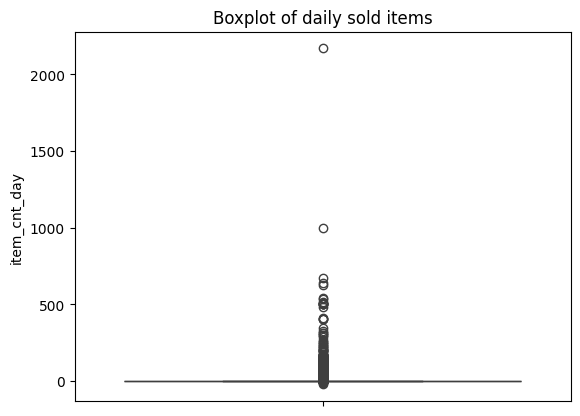

In [33]:
#Sales per day per shop and Item
sns.boxplot(y = 'item_cnt_day', data = train);
plt.title('Boxplot of daily sold items')
plt.savefig('./images/box_daily_count')

##### Observation
* The range is wide
* There seems to be outliers.
* Any daily sale per item per shop more than 1000 seems to be an outlier. So we can remove records with `item_cnt_day < 1000` and also less than zero.
* We will keep records with `item_cnt_day = 0`, as items may not sell every day.

We should also check for outliers based on item prices to make sure the total sale amount data does not have any negative values or values that are too high, which could be outliers.

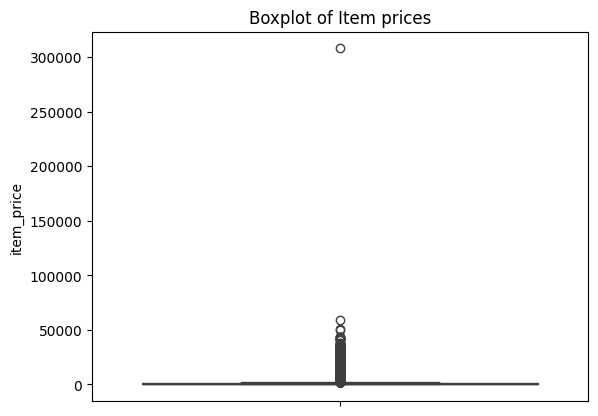

In [34]:
sns.boxplot(y = 'item_price', data = train);
plt.title('Boxplot of Item prices')
plt.savefig('./images/box_item_price')

#### Observations
* The range is wide here as well.
* There seem to be outliers.
* Any item with a price greater than 50000 seems to be an outlier.
* We can remove records with `item_price > 50000` and also less than or equal to 0.

In [35]:
train = train[train['item_price'] > 0]
train = train[train['item_price'] < 50000]

train = train[train['item_cnt_day'] > 0]
train = train[train['item_cnt_day'] < 1000]


Now lets check for any trends or insights we can find from the data.
1. How are the sales distributed across different months?
2. Which category and category type items sell more?
3. Which shops have more sales than others?
4. Does the city where the shop is located make any difference?


##### How the monthly sales are distributed across different months.

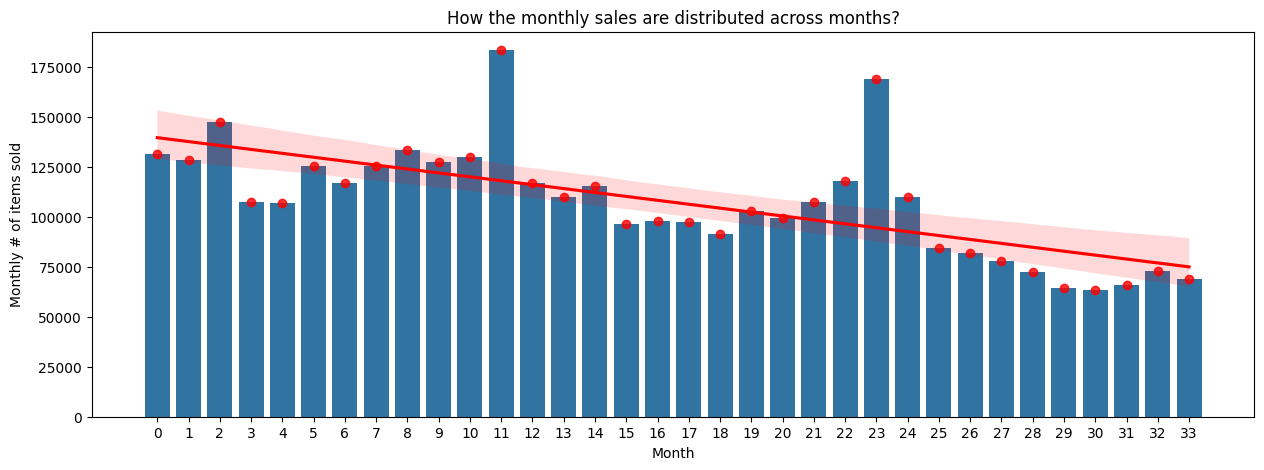

In [36]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 5)


monthly_sum = train.groupby('date_block_num').agg({'item_cnt_day': 'sum'}).reset_index()

ax = sns.barplot(x = 'date_block_num', y = 'item_cnt_day', data = monthly_sum)
sns.regplot(x='date_block_num', y='item_cnt_day', data=monthly_sum, color='red', ax=ax)
ax.set(title = 'How the monthly sales are distributed across months?',
       xlabel = 'Month',
       ylabel = 'Monthly # of items sold');
plt.savefig('./images/bar_monthly_items_sold')

#### Observation
* There seems to be an overall declining trend in the number of items sold
* There are couple of months where the sales have gone up and it could related to some promotions or events during those months.

##### Which shops have more sales than others?

In [37]:
train['item_cnt_day'] = pd.to_numeric(train['item_cnt_day'], errors='coerce')
shop_sum = (
    train.groupby('shop_id', as_index=False)
         .agg({'item_cnt_day': 'sum', 'sale_amount': 'sum'})
         .sort_values('item_cnt_day')
)


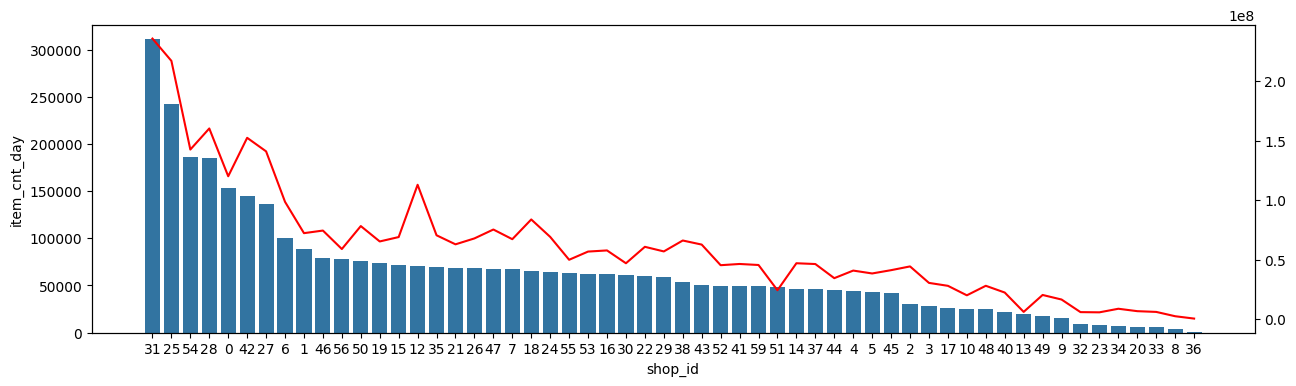

In [38]:
fig, ax1 = plt.subplots()
fig.set_size_inches(15, 4)
ax2 = ax1.twinx()

shop_sum = train.groupby('shop_id').agg({'item_cnt_day': 'sum', 'sale_amount' : 'sum'}).reset_index()
shop_sum = shop_sum.sort_values('item_cnt_day', ascending=False)
top_shops = shop_sum.iloc[:30]
order = shop_sum['shop_id']  # this preserves the sorted order
shop_sum['shop_id'] = pd.Categorical(
    shop_sum['shop_id'],
    categories=shop_sum['shop_id'],  # keep row order
    ordered=True
)
sns.barplot(x = 'shop_id', y = 'item_cnt_day', data = shop_sum, ax = ax1, order = order)
ax2.plot(range(len(shop_sum)), shop_sum['sale_amount'], color='red')
ax.set(title = 'Which shops have more sales than others?',
       xlabel = 'Month',
       ylabel = '# of items sold');
plt.savefig('./images/bar_shop_items_sold')

#### Observation
* Most of the shops have similar sales overall
* Few shops are selling below average
* A couple of shops are are "rockstars" with higher sales, such as shop ids 25, 28, 31, 42, and 54
* The total sale amount by each shop more or less follows the trend of number of items sold, with the exception of a couple of shops. This indicates these shops tend to sell costlier items.

##### Does the city where the shop is located make any difference?

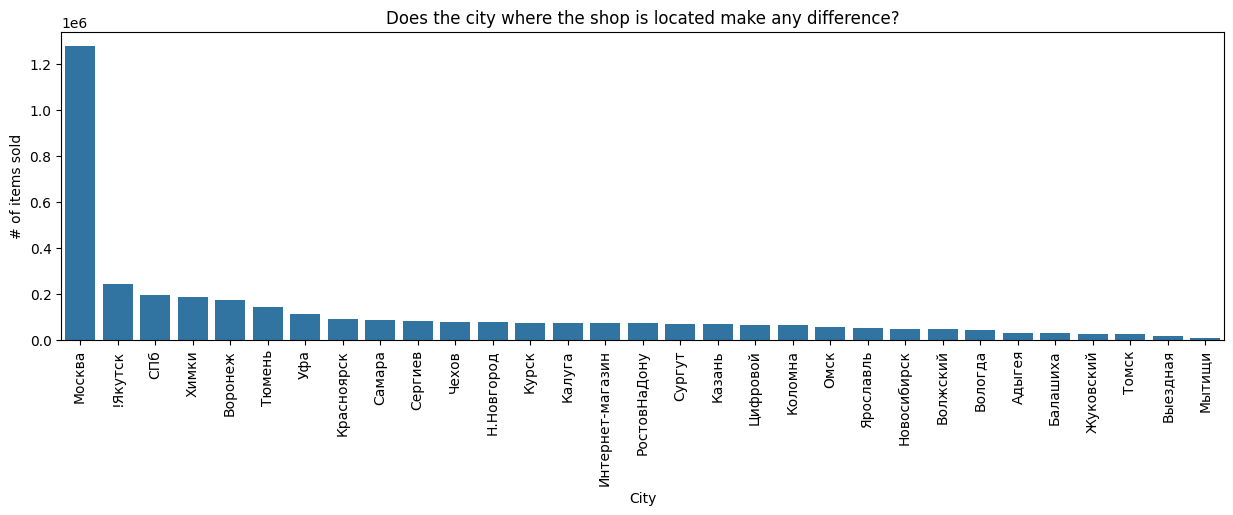

In [39]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 4)

city_sum = train.groupby('city').agg({'item_cnt_day': 'sum'}).reset_index()
city_sum = city_sum.sort_values('item_cnt_day', ascending = False)

sns.barplot(x = 'city', y = 'item_cnt_day', data = city_sum)
ax.set(title = 'Does the city where the shop is located make any difference?',
       xlabel = 'City',
       ylabel = '# of items sold');
ax.tick_params(axis = 'x', labelrotation = 90)
plt.savefig('./images/bar_city_shop_item_sold')

#### Observations
* "Москва", which is Russian for Moscow, seems to be the city where shops are selling the most.
* All other cities have way lower sales but are close in number to each other, with a couple of cities shining a bit.

##### Which category and category Type items sale more?

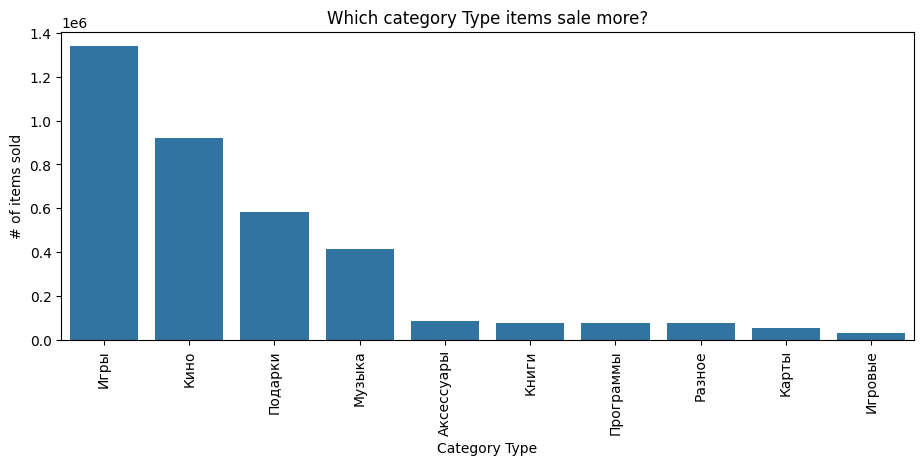

In [40]:
# We will first check by Category type
figure, ax = plt.subplots()
figure.set_size_inches(11, 4)

category_type_sum = train.groupby('category_type').agg({'item_cnt_day': 'sum'}).reset_index()
category_type_sum = category_type_sum.sort_values('item_cnt_day', ascending = False)

sns.barplot(x = 'category_type', y = 'item_cnt_day', data = category_type_sum)
ax.set(title = 'Which category Type items sale more?',
       xlabel = 'Category Type',
       ylabel = '# of items sold');
ax.tick_params(axis = 'x', labelrotation = 90)
plt.savefig('./images/bar_category_type_item_sold')

#### Observations
* Four category types are prominent, while all the others are close to each other in number.
* Игры i.e "Game", Кино i.e "Movies", Музыка i.e "Music" and Подарки i.e "Gifts" are prominent category types.

In [41]:
category_sum = train.groupby('item_category_id').agg({'item_cnt_day': 'sum'}).reset_index()
category_sum = category_sum.sort_values('item_cnt_day', ascending = False)
category_sum.head()

,item_category_id,item_cnt_day
40,40,634880
30,30,457343
55,55,349050
19,19,255746
37,37,204029


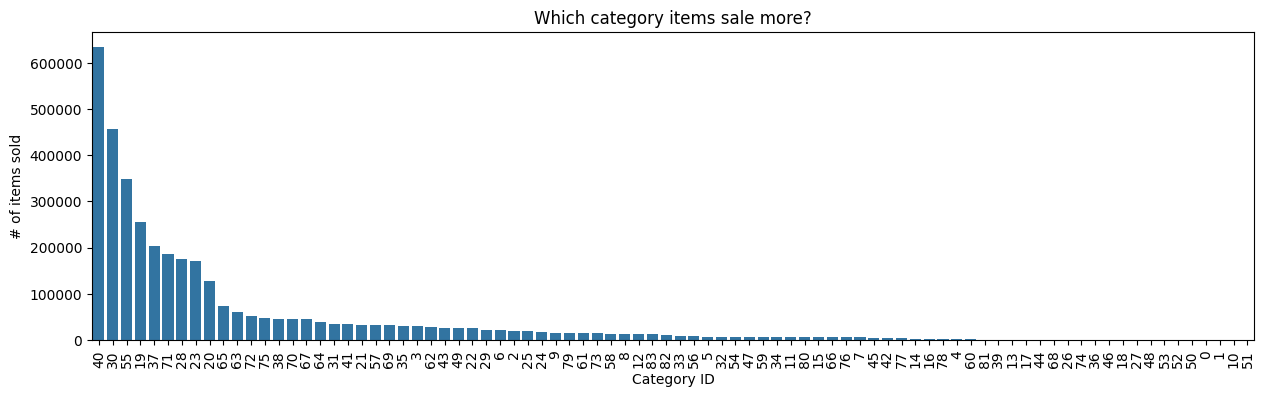

In [42]:
fig, ax = plt.subplots()
fig.set_size_inches(15, 4)

# Total sales by item category
category_sum = train.groupby('item_category_id').agg({'item_cnt_day': 'sum'}).reset_index()
category_sum = category_sum.sort_values('item_cnt_day', ascending = False)
order = category_sum['item_category_id']  # this preserves the sorted order
sns.barplot(x = 'item_category_id', y = 'item_cnt_day', data = category_sum, order = order)
ax.set(title = 'Which category items sale more?',
       xlabel = 'Category ID',
       ylabel = '# of items sold');
ax.tick_params(axis = 'x', labelrotation = 90)
plt.savefig('./images/bar_category_item_sold')

#### Observations
* Category ID 40 has the highest sales, followed by categories 30 and 55.
* Most of the category items are selling in very low range.
* This indicates that certain category item sell significantly more than others.

#### Encoding the categorical data

In [43]:
# Out of all the categorical features, City and Category_type are of more imporantace. So we will only encode them. Rest of the categorical features like shop name and item name can be ignored.
# LabelEncoding can be used though there is no specific order between the values, it will keep the number of features under control as oppose dto OneHotEncoding.

columns_to_encode = ['city', 'category_type']
for col in columns_to_encode:
    label_encoder = LabelEncoder()
    train[col] = label_encoder.fit_transform(train[col])
train.head()


,date,date_block_num,shop_id,item_id,item_price,item_cnt_day,sale_amount,shop_name,city,item_name,item_category_id,first_sold_month,item_category_name,category_type
0,02.01.2013,0,59,22154,999.00,1,999.00,"Ярославль ТЦ ""Альтаир""",30,ЯВЛЕНИЕ 2012 (BD),37,0.0,Кино - Blu-Ray,4
1,03.01.2013,0,25,2552,899.00,1,899.00,"Москва ТРК ""Атриум""",14,DEEP PURPLE The House Of Blue Light LP,58,0.0,Музыка - Винил,6
3,06.01.2013,0,25,2554,1709.05,1,1709.05,"Москва ТРК ""Атриум""",14,DEEP PURPLE Who Do You Think We Are LP,58,0.0,Музыка - Винил,6
4,15.01.2013,0,25,2555,1099.00,1,1099.00,"Москва ТРК ""Атриум""",14,DEEP PURPLE 30 Very Best Of 2CD (Фирм.),56,0.0,Музыка - CD фирменного производства,6
5,10.01.2013,0,25,2564,349.00,1,349.00,"Москва ТРК ""Атриум""",14,DEEP PURPLE Perihelion: Live In Concert DVD (К...,59,0.0,Музыка - Музыкальное видео,6


In [44]:
# group by date_block_num which represents month. 
train_monthly = train.groupby(['date_block_num', 'shop_id', 'item_id']).agg(
    item_cnt_month=('item_cnt_day', 'sum'),
    item_price=('item_price', 'mean'), 
    sale_amount=('sale_amount', 'sum'), 
    shop_name=('shop_name', 'first'),  
    city=('city', 'first'),  
    item_name=('item_name', 'first'), 
    item_category_id=('item_category_id', 'first'),  
    item_category_name=('item_category_name', 'first'),
    category_type=('category_type', 'first'),  
).reset_index()

train_monthly['month'] = (train_monthly['date_block_num'] % 12) + 1
train_monthly.head()

,date_block_num,shop_id,item_id,item_cnt_month,item_price,sale_amount,shop_name,city,item_name,item_category_id,item_category_name,category_type,month
0,0,0,32,6,221.0,1326.0,"!Якутск Орджоникидзе, 56 фран",0,1+1,40,Кино - DVD,4,1
1,0,0,33,3,347.0,1041.0,"!Якутск Орджоникидзе, 56 фран",0,1+1 (BD),37,Кино - Blu-Ray,4,1
2,0,0,35,1,247.0,247.0,"!Якутск Орджоникидзе, 56 фран",0,10 ЛЕТ СПУСТЯ,40,Кино - DVD,4,1
3,0,0,43,1,221.0,221.0,"!Якутск Орджоникидзе, 56 фран",0,100 МИЛЛИОНОВ ЕВРО,40,Кино - DVD,4,1
4,0,0,51,2,128.5,257.0,"!Якутск Орджоникидзе, 56 фран",0,100 лучших произведений классики (mp3-CD) (Dig...,57,Музыка - MP3,6,1


### Preparing test data

In [45]:
# We need to prepare the test data to add similar features as the train data based on the shop_id and item_id already present in the test data. This will aloow us to use the test data for predictions using the regression and other non-timeseries type models.
test.head()

,ID,shop_id,item_id
0,0,5,5037
1,1,5,5320
2,2,5,5233
3,3,5,5232
4,4,5,5268


In [46]:
test = test.merge(shops, on = 'shop_id', how = 'left')
test = test.merge(items, on = 'item_id', how = 'left')
test = test.merge(item_categories, on = 'item_category_id', how = 'left')
test['date_block_num'] = 34
test['month'] = (test['date_block_num'] % 12) + 1
test.head()

,ID,shop_id,item_id,shop_name,city,item_name,item_category_id,first_sold_month,item_category_name,category_type,date_block_num,month
0,0,5,5037,"Вологда ТРЦ ""Мармелад""",Вологда,"NHL 15 [PS3, русские субтитры]",19,20.0,Игры - PS3,Игры,34,11
1,1,5,5320,"Вологда ТРЦ ""Мармелад""",Вологда,ONE DIRECTION Made In The A.M.,55,34.0,Музыка - CD локального производства,Музыка,34,11
2,2,5,5233,"Вологда ТРЦ ""Мармелад""",Вологда,"Need for Speed Rivals (Essentials) [PS3, русск...",19,27.0,Игры - PS3,Игры,34,11
3,3,5,5232,"Вологда ТРЦ ""Мармелад""",Вологда,"Need for Speed Rivals (Classics) [Xbox 360, ру...",23,31.0,Игры - XBOX 360,Игры,34,11
4,4,5,5268,"Вологда ТРЦ ""Мармелад""",Вологда,"Need for Speed [PS4, русская версия]",20,34.0,Игры - PS4,Игры,34,11


In [47]:
columns_to_encode = ['city', 'category_type']
for col in columns_to_encode:
    label_encoder = LabelEncoder()
    test[col] = label_encoder.fit_transform(test[col])
test.head()

,ID,shop_id,item_id,shop_name,city,item_name,item_category_id,first_sold_month,item_category_name,category_type,date_block_num,month
0,0,5,5037,"Вологда ТРЦ ""Мармелад""",4,"NHL 15 [PS3, русские субтитры]",19,20.0,Игры - PS3,2,34,11
1,1,5,5320,"Вологда ТРЦ ""Мармелад""",4,ONE DIRECTION Made In The A.M.,55,34.0,Музыка - CD локального производства,6,34,11
2,2,5,5233,"Вологда ТРЦ ""Мармелад""",4,"Need for Speed Rivals (Essentials) [PS3, русск...",19,27.0,Игры - PS3,2,34,11
3,3,5,5232,"Вологда ТРЦ ""Мармелад""",4,"Need for Speed Rivals (Classics) [Xbox 360, ру...",23,31.0,Игры - XBOX 360,2,34,11
4,4,5,5268,"Вологда ТРЦ ""Мармелад""",4,"Need for Speed [PS4, русская версия]",20,34.0,Игры - PS4,2,34,11


### Baseline Modelling

Now that we have done a good amount of data cleaning, and some basic feature engineering, we will look into a baseline model. 

We have decided to use polynomial regression as a baseline model since the problem is a time-series problem. Though polynomial regression might be able to model the features relations, it may not yield good results. However, this can be a good starting point, and then we can build more sophisticated models and compare.

We will compare other models like LGBM, XGBoost, ARIMA with this baseline model. Before we start with these models, we will also perform additional feature engineering (in part 2) to make sure some timeline-specific features are added to the dataset. This will ensure that these non-timeseries models can be effectively trained.

Since the goal is to forecast item sales for each shop and each item, we will build a separate time-series model for each shop-item combination.


#### 1. Polynomial Regression

In [48]:
selected_features = ['date_block_num', 'shop_id', 'item_id', 'city', 'category_type', 'month']
condition = train_monthly['date_block_num'] < 32

X_train  = train_monthly.loc[condition, selected_features]
y_train = train_monthly.loc[condition,'item_cnt_month']
condition_val = train_monthly['date_block_num'] >= 32
X_val = train_monthly.loc[condition_val, selected_features]
y_val = train_monthly.loc[condition_val,'item_cnt_month']
X_test = test[selected_features]


In [49]:
poly_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: Scale features
    ('transform', PolynomialFeatures(include_bias = False)),
    ('lin_reg', LinearRegression())
])

param_grid = {
    'transform__degree': [2, 3, 4],  # Degrees to test for polynomial features
    'lin_reg__fit_intercept': [True, False] # Whether to calculate the intercept for the linear model
}


grid_search = GridSearchCV(poly_pipeline, param_grid, cv=5, scoring='neg_root_mean_squared_error', verbose=0)
print("Executing GridSearchCV")
grid_search.fit(X_train, y_train)

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Best negative RMSE found: {grid_search.best_score_}")

# Evaluate the best model on the test set
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_val)
test_rmse = root_mean_squared_error(y_val, y_pred)
print(f"Test MSE of the best model: {test_rmse}")



Executing GridSearchCV
Best parameters found: {'lin_reg__fit_intercept': True, 'transform__degree': 2}
Best negative RMSE found: -7.9029198619896475
Test MSE of the best model: 13.80958638330015


In [50]:
y_test_pred = best_model.predict(X_test)

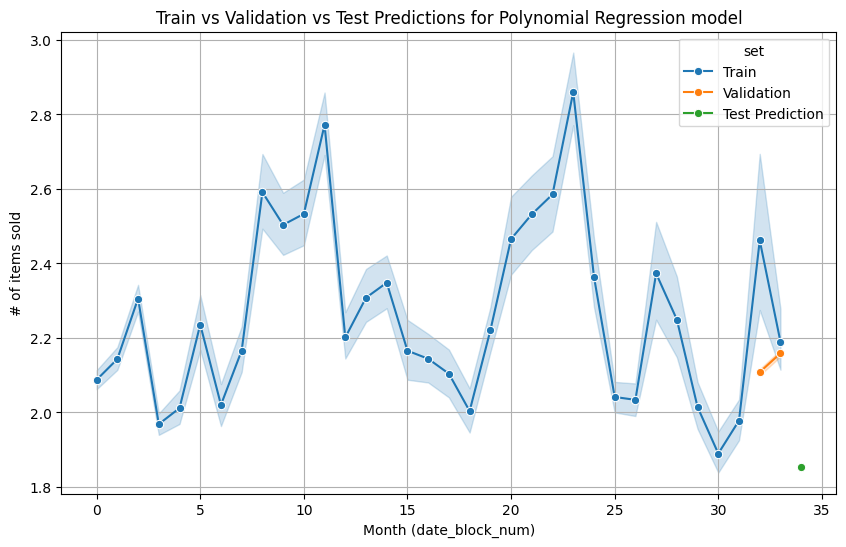

In [51]:

df_train = pd.DataFrame({
    #'date_block_num': X_train['date_block_num'],
    'date_block_num': train_monthly.loc[train_monthly['date_block_num'] < 34, 'date_block_num'],
    'item_cnt_month': train_monthly.loc[train_monthly['date_block_num'] < 34, 'item_cnt_month'],
    'set': 'Train'
})

df_val = pd.DataFrame({
    'date_block_num': X_val['date_block_num'],
    'item_cnt_month': y_pred,
    'set': 'Validation'
})

df_test = pd.DataFrame({
    'date_block_num': X_test['date_block_num'],
    'item_cnt_month': y_test_pred,
    'set': 'Test Prediction'
})

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Now plot in one call
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all, x='date_block_num', y='item_cnt_month', hue='set', marker = 'o')

plt.title('Train vs Validation vs Test Predictions for Polynomial Regression model')
plt.xlabel('Month (date_block_num)')
plt.ylabel('# of items sold')
plt.grid(True)

plt.savefig('./images/ploy_preds')

#### 2. ARIMA model

We will test with one sample `shop_id` and `item_id` first as a dry run.
Since every item may not sell in every month, we will fill the dataframe with filler records for months when the item was not sold.

In [52]:
store_1_item_30 = train_monthly[(train_monthly['shop_id'] == 0) & (train_monthly['item_id'] == 30)]
store_1_item_30 = store_1_item_30.set_index("date_block_num")
store_1_item_30.head()


,shop_id,item_id,item_cnt_month,item_price,sale_amount,shop_name,city,item_name,item_category_id,item_category_name,category_type,month
date_block_num,,,,,,,,,,,,
1,0,30,31,265.0,8215.0,"!Якутск Орджоникидзе, 56 фран",0,007: КООРДИНАТЫ «СКАЙФОЛЛ»,40,Кино - DVD,4,2
2,0,30,24,399.0,9576.0,"!Якутск Орджоникидзе, 56 фран",0,007: КООРДИНАТЫ «СКАЙФОЛЛ»,40,Кино - DVD,4,3
3,0,30,3,399.0,1197.0,"!Якутск Орджоникидзе, 56 фран",0,007: КООРДИНАТЫ «СКАЙФОЛЛ»,40,Кино - DVD,4,4
4,0,30,1,399.0,399.0,"!Якутск Орджоникидзе, 56 фран",0,007: КООРДИНАТЫ «СКАЙФОЛЛ»,40,Кино - DVD,4,5
6,0,30,1,399.0,399.0,"!Якутск Орджоникидзе, 56 фран",0,007: КООРДИНАТЫ «СКАЙФОЛЛ»,40,Кино - DVD,4,7


In [53]:

# Create full daily date range
full_range = pd.Index(range(0, 35))
# Reindex and fill missing with 0
store_1_item_30 = store_1_item_30.reindex(full_range, fill_value=0)

# Rename index back to 'date'
#store_1_item_30.index.name = "month"

store_1_item_30.tail()



,shop_id,item_id,item_cnt_month,item_price,sale_amount,shop_name,city,item_name,item_category_id,item_category_name,category_type,month
30,0,0,0,0.0,0.0,0,0,0,0,0,0,0
31,0,30,1,129.0,129.0,"!Якутск Орджоникидзе, 56 фран",0,007: КООРДИНАТЫ «СКАЙФОЛЛ»,40,Кино - DVD,4,8
32,0,0,0,0.0,0.0,0,0,0,0,0,0,0
33,0,0,0,0.0,0.0,0,0,0,0,0,0,0
34,0,0,0,0.0,0.0,0,0,0,0,0,0,0


In [54]:
X_train_1_30, X_val_1_30, X_test_1_30 = store_1_item_30.iloc[:-3], store_1_item_30.iloc[-3:-1], store_1_item_30.iloc[-1:]

In [55]:
X_val_1_30.tail()

,shop_id,item_id,item_cnt_month,item_price,sale_amount,shop_name,city,item_name,item_category_id,item_category_name,category_type,month
32,0,0,0,0.0,0.0,0,0,0,0,0,0,0
33,0,0,0,0.0,0.0,0,0,0,0,0,0,0


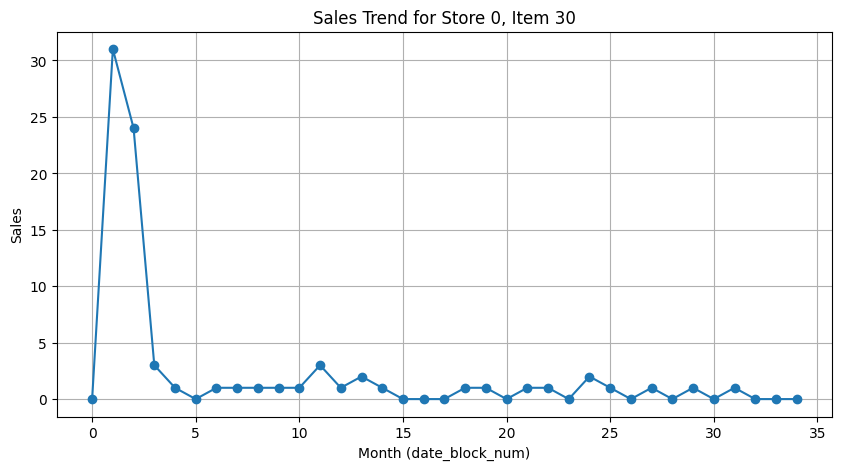

In [56]:
plt.figure(figsize=(10,5))
plt.plot(store_1_item_30.index, store_1_item_30['item_cnt_month'], marker='o', linestyle='-')

plt.title('Sales Trend for Store 0, Item 30')
plt.xlabel('Month (date_block_num)')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [57]:
result = adfuller(X_train_1_30['item_cnt_month'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])


# If p-value < 0.05, the series is likely stationary.

# If p-value >= 0.05, the series is non-stationary and needs differencing.

if result[1] < 0.05:
  print("The series is likely stationary.")
else:
  print("The series is non-stationary and needs differencing.")

ADF Statistic: -3.2903510774818674
p-value: 0.015315329557108391
The series is likely stationary.


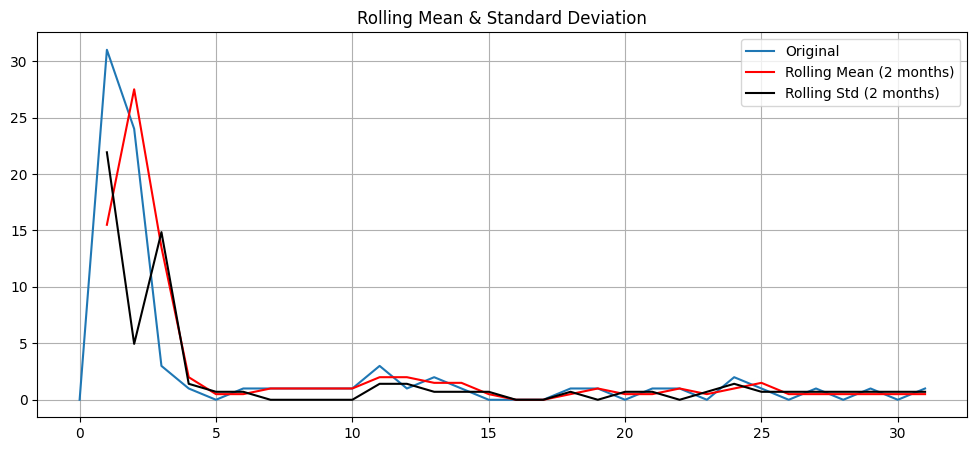

In [58]:

#  in a stationary series, the rolling mean and std should be relatively flat over time.

# Compute rolling statistics
rolling_mean = X_train_1_30['item_cnt_month'].rolling(window=2).mean()
rolling_std = X_train_1_30['item_cnt_month'].rolling(window=2).std()

# Plot original series with rolling mean and std
plt.figure(figsize=(12, 5))
plt.plot(X_train_1_30['item_cnt_month'], label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean (2 months)')
plt.plot(rolling_std, color='black', label='Rolling Std (2 months)')
plt.title('Rolling Mean & Standard Deviation')
plt.legend()
plt.grid(True)
plt.show()


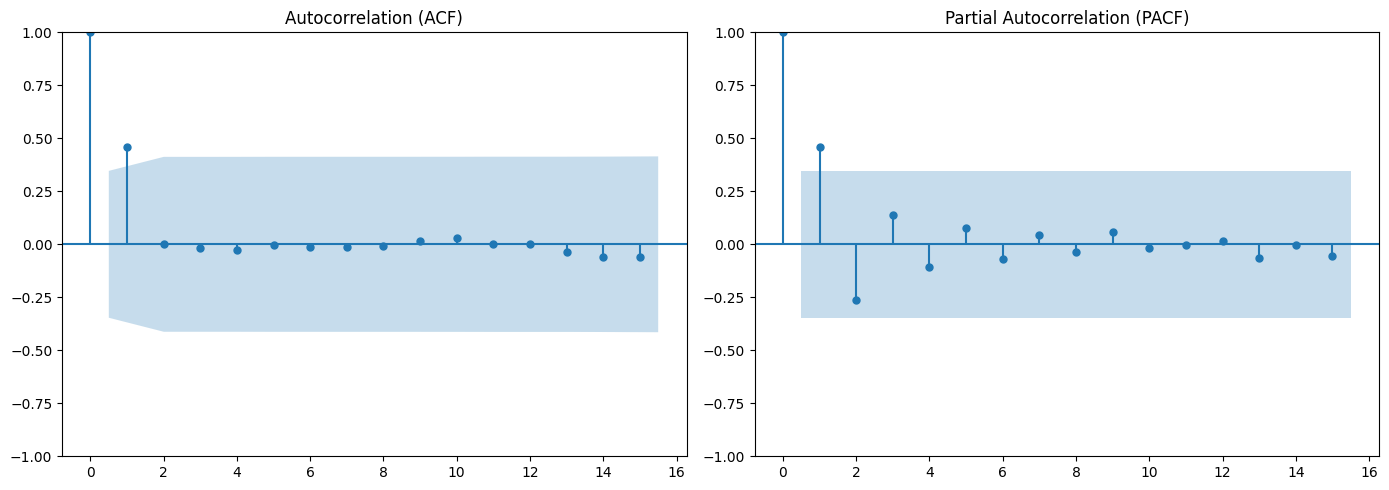

In [59]:


plt.figure(figsize=(14, 5))

# ACF
plt.subplot(1, 2, 1)
plot_acf(X_train_1_30['item_cnt_month'], lags=15, ax=plt.gca())
plt.title('Autocorrelation (ACF)')

# PACF
plt.subplot(1, 2, 2)
plot_pacf(X_train_1_30['item_cnt_month'], lags=15, ax=plt.gca(), method='ywm')
plt.title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()

In [60]:
y_train_1_30 = X_train_1_30['item_cnt_month']
# Fit ARIMA model (p=1, d=0, q=1)
model = ARIMA(y_train_1_30, order=(1, 0, 1))
arma = model.fit()

# Forecast next 2 months
preds = arma.forecast(steps=3)
preds_val = arma.forecast(steps=2)
preds_test = arma.forecast(steps=3)[-1:]
# Make sure y_test matches length (2 months here)
y_val_1_30 = X_val_1_30['item_cnt_month']  

# Compute MSE
rmse_val = root_mean_squared_error(y_val_1_30, preds_val)

print('Validation set RMSE:', rmse_val)
print(preds_val)
print(preds_test)

Validation set RMSE: 3.3117371114205563
32    4.023218
33    2.397692
Name: predicted_mean, dtype: float64
34    2.165497
Name: predicted_mean, dtype: float64


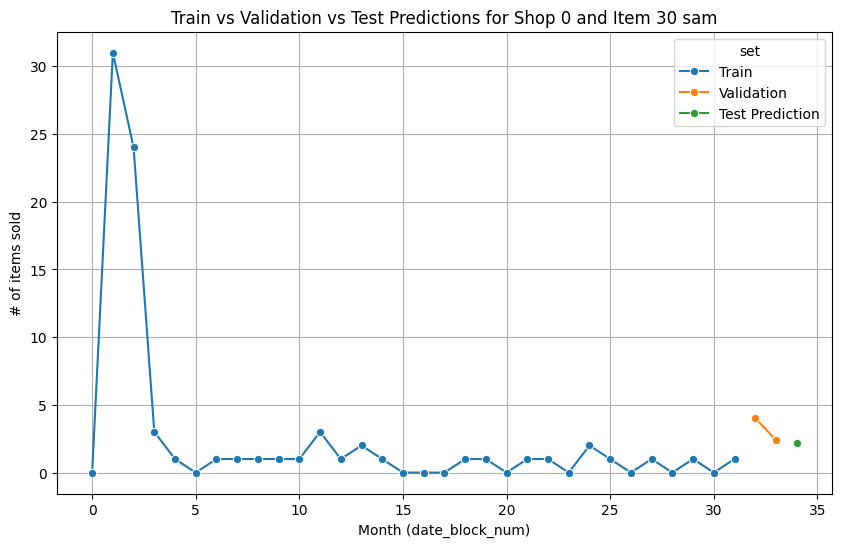

In [61]:
df_train_1_30 = pd.DataFrame({
    'date_block_num': X_train_1_30.index,
    'item_cnt_month': X_train_1_30['item_cnt_month'],
    'set': 'Train'
})

df_val_1_30 = pd.DataFrame({
    'date_block_num': X_val_1_30.index,
    'item_cnt_month': preds_val,
    'set': 'Validation'
})

df_test_1_30 = pd.DataFrame({
    'date_block_num': X_test_1_30.index,
    'item_cnt_month': preds_test,
    'set': 'Test Prediction'
})

df_all_1_30 = pd.concat([df_train_1_30, df_val_1_30, df_test_1_30], ignore_index=True)

# Now plot in one call
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all_1_30, x='date_block_num', y='item_cnt_month', hue='set', marker = 'o')

plt.title('Train vs Validation vs Test Predictions for Shop 0 and Item 30 sam')
plt.xlabel('Month (date_block_num)')
plt.ylabel('# of items sold')
plt.grid(True)

plt.savefig('./images/ARIMA_oneStore_preds')

Based on one sample Modelling task, we can now build time series ARMA model for each shop-item combo programatically.
    

In [62]:
shops_list = train_monthly['shop_id'].unique()
items_list = train_monthly['item_id'].unique()
items_list.shape

(21802,)

In [63]:
shops_list

array([ 0,  1,  2,  3,  4,  6,  7,  8, 10, 12, 13, 14, 15, 16, 18, 19, 21,
       22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 35, 37, 38, 41, 42, 43,
       44, 45, 46, 47, 50, 51, 52, 53, 54, 56, 59,  5, 55, 17,  9, 49, 40,
       48, 34, 33, 20, 36], dtype=int8)

In [64]:
final_results = {}
skipped = []
k = 0
full_range = pd.Index(range(0, 35))
for shop_id in shops_list:
    for item_id in items_list:
        k += 1
        print(f"\rProcessing: {k}th - {shop_id}_{item_id}", end="")
        # filter records for shop_id-item_id combination
        store_item_df = train_monthly[(train_monthly['shop_id'] == shop_id) & (train_monthly['item_id'] == item_id)]
        store_item_df = store_item_df.set_index('date_block_num')
        # Not every item will sell in every shop, so only if at least one item has sold in the given shop proceed, else check for next item.
        if len(store_item_df) > 0:
            # Since items may not sell on every day, insert 0 count records for days when the item is not sold.
            # Create full daily date range
            store_min_index = store_item_df.index.min()
            store_max_index = store_item_df.index.max()
            threshold = 31
            if store_min_index > threshold:
                skipped.append(str(shop_id) + "-" + str(item_id))
                continue
            store_item_df = store_item_df.reindex(full_range, fill_value=0)
                
            # create Training dataset with all days except last 2 months. Last 2 months records will go in the test set.
            X_train, X_val, X_test = store_item_df.iloc[:-3], store_item_df.iloc[-3:-1], store_item_df.iloc[-1:]
            # Now we need to find the AD Fuller stats to determine if the timeseries is stationary or not.
            result = adfuller(X_train['item_cnt_month'])
            p_value = result[1]
            # If p-value < 0.05, the series is likely stationary
            # If p-value >= 0.05, the series is non-stationary and needs differencing.
            i = 0
            if p_value >= 0.05:
                while p_value >= 0.05 and i<= 4:
                    i += 1
                    X_train_Item_cnt_diff = X_train['item_cnt_month'].diff().dropna()
                    p_value = adfuller(X_train_Item_cnt_diff)[1]
                y_train = X_train_Item_cnt_diff
            else:
                y_train = X_train['item_cnt_month']
            # Fit ARIMA model (p=1, d=i, q=1)
            model = ARIMA(y_train, order=(1, i, 1))
            arma = model.fit()
                
            # Forecast next 3 months ( 2 from validation set and 1 from test set.
            preds_val = arma.forecast(steps=2)
            preds_test = arma.forecast(steps=3)[-1:]
            results = {}
            #results['y_train'] = y_train
            results['preds_val'] = preds_val
            results['preds_test'] = preds_test
            y_val = X_val['item_cnt_month']  
                
            # Compute MSE
            mse_val = root_mean_squared_error(y_val, preds_val)
            results['rmse'] = mse_val
            #results['fit_model'] = arma
            id = str(shop_id) + "-" + str(item_id)
            final_results[id] = results

Processing: 1220912th - 36_18060

In [65]:
i = 1
result_df = pd.DataFrame(columns=['shop_id', 'item_id', 'rmse'])
training_df = pd.DataFrame(columns = ['date_block_num','item_cnt_month','set'])
validation_df = pd.DataFrame(columns = ['date_block_num','item_cnt_month','set'])
test_df = pd.DataFrame(columns = ['date_block_num','item_cnt_month','set'])
for id in final_results:
    #if i == 10:
    #    break
    mse  = final_results[id]['rmse']
    preds_val = final_results[id]['preds_val']
    preds_test = final_results[id]['preds_test']
    shop_id, item_id = id.split("-")
    train_df = train_monthly[(train_monthly['shop_id'] == shop_id) & (train_monthly['item_id'] == item_id)]
    new_train_df =  pd.DataFrame({
        'date_block_num': train_df['date_block_num'],
        'item_cnt_month': train_df['item_cnt_month'],
        'set': 'Train'
    })
    new_val_df = pd.DataFrame({
    'date_block_num': [32,33],
    'item_cnt_month': preds_val,
    'set': 'Validation Prediction'
    })

    new_test_df = pd.DataFrame({
        'date_block_num': [34],
        'item_cnt_month': preds_test,
        'set': 'Test Prediction'
    })
    training_df = pd.concat([training_df, new_train_df], ignore_index=True)
    validation_df = pd.concat([validation_df, new_val_df], ignore_index=True)
    test_df = pd.concat([test_df, new_test_df], ignore_index=True)
    
    new_rows_df = pd.DataFrame({'shop_id': [shop_id], 'item_id': [item_id], 'rmse' : [mse]})
    result_df = pd.concat([result_df, new_rows_df], ignore_index=True)
    #print(mse)
    #print(preds.keys())
    #i +=1
    
result_df.head()
#del item_cnt_list, month_list, new_rows_df
#gc.collect()

,shop_id,item_id,rmse
0,0,32,0.812052
1,0,33,1.600169
2,0,35,0.483649
3,0,43,0.093719
4,0,51,0.419806


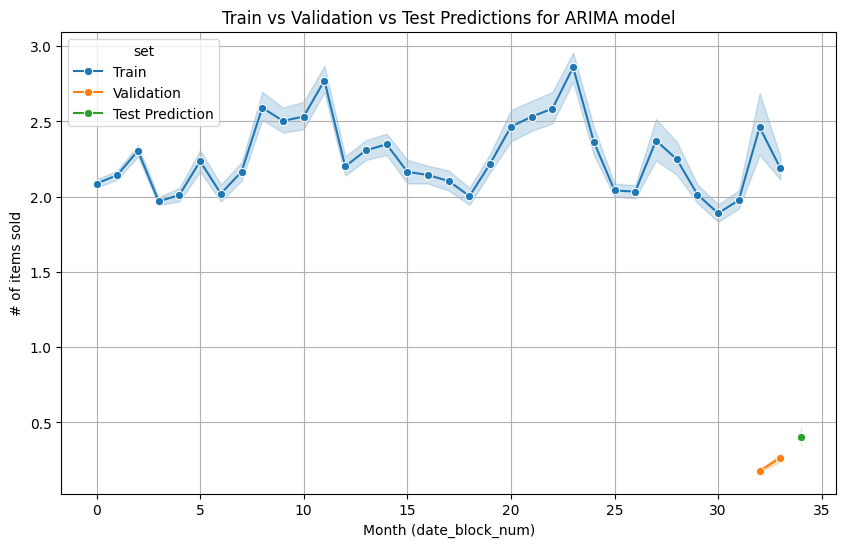

In [66]:
temp_train = train_monthly[train_monthly['date_block_num']< 34]

df_train = pd.DataFrame({
    'date_block_num': temp_train['date_block_num'],
    'item_cnt_month': temp_train['item_cnt_month'],
    'set': 'Train'
})

df_val = pd.DataFrame({
    'date_block_num': validation_df['date_block_num'],
    'item_cnt_month': validation_df['item_cnt_month'],
    'set': 'Validation'
})

df_test= pd.DataFrame({
    'date_block_num': test_df['date_block_num'],
    'item_cnt_month': test_df['item_cnt_month'],
    'set': 'Test Prediction'
})

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)

# Now plot in one call
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all, x='date_block_num', y='item_cnt_month', hue='set', marker = 'o')

plt.title('Train vs Validation vs Test Predictions for ARIMA model')
plt.xlabel('Month (date_block_num)')
plt.ylabel('# of items sold')
plt.grid(True)
plt.savefig('./images/ARIMA_preds')

#### 3. Ensamble Modeling

#### Feature engineering for Ensamble Models

In [67]:
# to prepare the data fro LGBM model, we will create a new Dataframe with combinations of all unique shop_id and item_ids that had sale every month. this will be 
# helpful as all items will not sell in every store.

temp_train = []

for i in train_monthly['date_block_num'].unique():
    all_shops = train_monthly.loc[train_monthly['date_block_num'] == i, 'shop_id'].unique()
    all_items = train_monthly.loc[train_monthly['date_block_num'] == i, 'item_id'].unique()
    temp_train.append(np.array(list(product([i], all_shops, all_items))))


id_features = ['date_block_num', 'shop_id', 'item_id']

train = pd.DataFrame(np.vstack(temp_train), columns = id_features)
train.head()

,date_block_num,shop_id,item_id
0,0,0,32
1,0,0,33
2,0,0,35
3,0,0,43
4,0,0,51


In [68]:
# Now add aggregate features. We will add Total sale amount for each item and the mean price for each Item.
group = train_monthly.groupby(id_features).agg({'item_cnt_month': 'sum', 
                                               'item_price': 'mean'})
group = group.reset_index().rename(columns = {'item_cnt_month': 'monthly_sales',
                                              'item_price': 'mean_price'})
group.head()

,date_block_num,shop_id,item_id,monthly_sales,mean_price
0,0,0,32,6,221.0
1,0,0,33,3,347.0
2,0,0,35,1,247.0
3,0,0,43,1,221.0
4,0,0,51,2,128.5


In [69]:
train = train.merge(group, on = id_features, how = 'left')
train.head()

,date_block_num,shop_id,item_id,monthly_sales,mean_price
0,0,0,32,6.0,221.0
1,0,0,33,3.0,347.0
2,0,0,35,1.0,247.0
3,0,0,43,1.0,221.0
4,0,0,51,2.0,128.5


In [70]:
import gc
del group
gc.collect();

In [71]:
train = train.merge(shops , on = 'shop_id', how = 'left')
train = train.merge(items, on = 'item_id', how = 'left')
train = train.merge(item_categories, on = 'item_category_id', how = 'left')

In [72]:
train['month'] = train['date_block_num'] % 12

In [73]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10812768 entries, 0 to 10812767
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   date_block_num      int16  
 1   shop_id             int16  
 2   item_id             int16  
 3   monthly_sales       float64
 4   mean_price          float64
 5   shop_name           object 
 6   city                object 
 7   item_name           object 
 8   item_category_id    int8   
 9   first_sold_month    float64
 10  item_category_name  object 
 11  category_type       object 
 12  month               int16  
dtypes: float64(3), int16(4), int8(1), object(5)
memory usage: 752.8+ MB


In [74]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214200 entries, 0 to 214199
Data columns (total 12 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ID                  214200 non-null  int32  
 1   shop_id             214200 non-null  int8   
 2   item_id             214200 non-null  int16  
 3   shop_name           214200 non-null  object 
 4   city                214200 non-null  int64  
 5   item_name           214200 non-null  object 
 6   item_category_id    214200 non-null  int8   
 7   first_sold_month    214200 non-null  float64
 8   item_category_name  214200 non-null  object 
 9   category_type       214200 non-null  int64  
 10  date_block_num      214200 non-null  int64  
 11  month               214200 non-null  int64  
dtypes: float64(1), int16(1), int32(1), int64(4), int8(2), object(3)
memory usage: 14.7+ MB


##### Before we concatenate the train and test datasets, we need to encode the train dataset's `city` and `category_type` columns, as these are already encoded in the test dataset.

In [75]:
columns_to_encode = ['city', 'category_type']
for col in columns_to_encode:
    label_encoder = LabelEncoder()
    train[col] = label_encoder.fit_transform(train[col])

In [76]:
train_all_data = pd.concat([train, test.drop('ID', axis = 1)], ignore_index = True,  keys = id_features)

In [77]:
train_all_data = train_all_data.fillna(0)

In [78]:
train_all_data.head()

,date_block_num,shop_id,item_id,monthly_sales,mean_price,shop_name,city,item_name,item_category_id,first_sold_month,item_category_name,category_type,month
0,0,0,32,6.0,221.0,"!Якутск Орджоникидзе, 56 фран",0,1+1,40,0.0,Кино - DVD,4,0
1,0,0,33,3.0,347.0,"!Якутск Орджоникидзе, 56 фран",0,1+1 (BD),37,0.0,Кино - Blu-Ray,4,0
2,0,0,35,1.0,247.0,"!Якутск Орджоникидзе, 56 фран",0,10 ЛЕТ СПУСТЯ,40,0.0,Кино - DVD,4,0
3,0,0,43,1.0,221.0,"!Якутск Орджоникидзе, 56 фран",0,100 МИЛЛИОНОВ ЕВРО,40,0.0,Кино - DVD,4,0
4,0,0,51,2.0,128.5,"!Якутск Орджоникидзе, 56 фран",0,100 лучших произведений классики (mp3-CD) (Dig...,57,0.0,Музыка - MP3,6,0


##### Now we add mean (average) features that represent the following:
1. Monthly average number of items sold for each item across all stores
2. Monthly average number of items sold for each item in each city across all stores with that city
3. Monthly average number of items sold for each category in each shop
   
These average features will be used later to add lag features that is most important for LGBM model training.

In [79]:
def add_mean_features(data, id_features):
    assert (id_features[0] == 'date_block_num') and len(id_features) in [2, 3]

    if len(id_features) == 2:
        new_feature_name = f"mean_by_{id_features[1]}"
    else:
        new_feature_name = f"mean_by_{id_features[1]}_{id_features[2]}"

    group = data.groupby(id_features).agg({'monthly_sales': 'mean'}).reset_index().rename(columns = {'monthly_sales': new_feature_name})

    data = data.merge(group, on = id_features, how = 'left')
    data = compress(data, verbose = False)
    new_feature_name

    del group
    gc.collect()

    return data, new_feature_name

In [80]:
new_item_feature_list = []

# Create a feature for the monthly average sales grouped by date_block_num and item_id
train_all_data, new_item_features = add_mean_features(data = train_all_data, id_features = ['date_block_num', 'item_id'])
new_item_feature_list.append(new_item_features)

# Create a feature for the monthly average sales grouped by date_block_num, item_id, and city 
train_all_data, new_item_features = add_mean_features(data = train_all_data, id_features = ['date_block_num', 'item_id', 'city'])
new_item_feature_list.append(new_item_features)


In [81]:
new_shop_feature_list = []

# Create a feature for the monthly average sales grouped by date_block_num, shop_id, and item_category_id
train_all_data, new_shop_features = add_mean_features(data = train_all_data, id_features = ['date_block_num', 'shop_id', 'item_category_id'])
new_shop_feature_list.append(new_shop_features)

# Create a feature for the monthly average sales grouped by date_block_num, shop_id and item_id, 
train_all_data, new_shop_features = add_mean_features(data = train_all_data, id_features = ['date_block_num', 'shop_id', 'item_id'])
new_shop_feature_list.append(new_shop_features)
train_all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11026968 entries, 0 to 11026967
Data columns (total 17 columns):
 #   Column                            Dtype  
---  ------                            -----  
 0   date_block_num                    int8   
 1   shop_id                           int8   
 2   item_id                           int16  
 3   monthly_sales                     int16  
 4   mean_price                        float64
 5   shop_name                         object 
 6   city                              int8   
 7   item_name                         object 
 8   item_category_id                  int8   
 9   first_sold_month                  int8   
 10  item_category_name                object 
 11  category_type                     int8   
 12  month                             int8   
 13  mean_by_item_id                   float32
 14  mean_by_item_id_city              float32
 15  mean_by_shop_id_item_category_id  float32
 16  mean_by_shop_id_item_id           

##### Now we need to add lag features for the four mean features we just added

In [82]:
def add_lag_features(data,lag_features, id_features, feature_to_lag, n = 3):
    data_temp = data[id_features + [feature_to_lag]].copy()
    for i in range(1, n + 1):
        lag_feature_name = feature_to_lag + '_lag' + str(i)
        data_temp.columns = id_features + [lag_feature_name]
        data_temp['date_block_num'] += 1
        data = data.merge(data_temp.drop_duplicates(), on = id_features, how = 'left')
        data[lag_feature_name] = data[lag_feature_name].fillna(0)
        lag_features.append(lag_feature_name)

    data = compress(data, False)
    del data_temp
    gc.collect()

    return data, lag_features

In [83]:
lag_features = []
train_all_data, lag_features = add_lag_features(data = train_all_data, 
                                                 lag_features = lag_features,
                                                 id_features = id_features,
                                                 feature_to_lag = 'monthly_sales',
                                                 n = 3)

In [84]:
train_all_data, lag_features = add_lag_features(data = train_all_data, 
                                                 lag_features = lag_features,
                                                 id_features = id_features,
                                                 feature_to_lag = 'mean_price',
                                                 n = 3)

In [85]:
for item_feature in new_item_feature_list:
    train_all_data, lag_features = add_lag_features(data = train_all_data, 
                                                 lag_features = lag_features,
                                                 id_features = id_features,
                                                 feature_to_lag = item_feature,
                                                 n = 3)

In [86]:
for shop_feature in new_shop_feature_list:
    train_all_data, lag_features = add_lag_features(data = train_all_data, 
                                                 lag_features = lag_features,
                                                 id_features = id_features,
                                                 feature_to_lag = shop_feature,
                                                 n = 3)

##### Since we have added lag features with 3 months of lag, we need to delete the first three months' records, so it will not bias the model thinking the initial sale value is zero.
##### We will also drop the mean columns which we used to add lag features, as these will not be available during inference.

In [87]:
train_all_data = train_all_data[train_all_data.date_block_num > 2]

In [88]:
train_all_data = train_all_data.drop(new_item_feature_list, axis = 1)
train_all_data = train_all_data.drop(new_shop_feature_list, axis = 1)

In [89]:
train_all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9904582 entries, 1122386 to 11026967
Data columns (total 31 columns):
 #   Column                                 Dtype  
---  ------                                 -----  
 0   date_block_num                         int8   
 1   shop_id                                int8   
 2   item_id                                int16  
 3   monthly_sales                          int16  
 4   mean_price                             float64
 5   shop_name                              object 
 6   city                                   int8   
 7   item_name                              object 
 8   item_category_id                       int8   
 9   first_sold_month                       int8   
 10  item_category_name                     object 
 11  category_type                          int8   
 12  month                                  int8   
 13  monthly_sales_lag1                     int16  
 14  monthly_sales_lag2                     int16  
 

In [90]:
train_all_data.describe().round(2)

,date_block_num,shop_id,item_id,monthly_sales,mean_price,city,item_category_id,first_sold_month,category_type,month,...,mean_by_item_id_lag3,mean_by_item_id_city_lag1,mean_by_item_id_city_lag2,mean_by_item_id_city_lag3,mean_by_shop_id_item_category_id_lag1,mean_by_shop_id_item_category_id_lag2,mean_by_shop_id_item_category_id_lag3,mean_by_shop_id_item_id_lag1,mean_by_shop_id_item_id_lag2,mean_by_shop_id_item_id_lag3
count,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,...,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00,9904582.00
mean,16.93,29.02,11298.29,0.33,116.01,15.02,44.96,6.38,4.60,5.77,...,0.33,0.33,0.33,0.32,0.28,0.28,0.27,0.33,0.33,0.33
std,8.98,17.58,6228.57,3.45,658.98,8.11,15.28,8.41,1.82,3.30,...,2.09,2.91,2.83,2.81,2.61,2.55,2.53,3.31,3.24,3.22
min,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,9.00,14.00,5896.00,0.00,0.00,9.00,37.00,0.00,4.00,3.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,16.00,28.00,11391.00,0.00,0.00,14.00,40.00,2.00,4.00,6.00,...,0.08,0.00,0.00,0.00,0.11,0.11,0.10,0.00,0.00,0.00
75%,24.00,45.00,16586.00,0.00,0.00,21.00,55.00,11.00,6.00,9.00,...,0.24,0.10,0.10,0.09,0.27,0.26,0.25,0.00,0.00,0.00
max,34.00,59.00,22169.00,1644.00,49782.00,30.00,83.00,34.00,9.00,11.00,...,272.98,1242.00,1127.00,1127.00,1305.00,1305.00,1305.00,1305.00,1305.00,1305.00


##### Now, let's add mean and standard deviation lag features for the 6 sets of lag features we have added. This is to capture the mean trend over the 3 month window and to smooth out noise.

In [91]:
lag_cols = [f"monthly_sales_lag{i}" for i in range(1, 4)]
train_all_data['monthly_sales_lag_mean'] = train_all_data[lag_cols].mean(axis=1)
train_all_data['monthly_sales_lag_std'] = train_all_data[lag_cols].std(axis=1)

lag_cols = [f"mean_price_lag{i}" for i in range(1, 4)]
train_all_data['mean_price_lag_mean'] = train_all_data[lag_cols].mean(axis=1)
train_all_data['mean_price_lag_std'] = train_all_data[lag_cols].std(axis=1)


lag_cols = [f"mean_by_item_id_lag{i}" for i in range(1, 4)]
train_all_data['mean_by_item_id_lag_mean'] = train_all_data[lag_cols].mean(axis=1)
train_all_data['mean_by_item_id_lag_std'] = train_all_data[lag_cols].std(axis=1)


lag_cols = [f"mean_by_item_id_city_lag{i}" for i in range(1, 4)]
train_all_data['mean_by_item_id_city_lag_mean'] = train_all_data[lag_cols].mean(axis=1)
train_all_data['mean_by_item_id_city_lag_std'] = train_all_data[lag_cols].std(axis=1)


lag_cols = [f"mean_by_shop_id_item_category_id_lag{i}" for i in range(1, 4)]
train_all_data["mean_by_shop_id_item_category_id_lag_mean"] = train_all_data[lag_cols].mean(axis=1)
train_all_data["mean_by_shop_id_item_category_id_lag_std"] = train_all_data[lag_cols].std(axis=1)


lag_cols = [f"mean_by_shop_id_item_id_lag{i}" for i in range(1, 4)]
train_all_data['mean_by_shop_id_item_id_lag_mean'] = train_all_data[lag_cols].mean(axis=1)
train_all_data['mean_by_shop_id_item_id_lag_std'] = train_all_data[lag_cols].std(axis=1)


##### Since the original training dataset had `True` target values clipped into `[0,20]` range, and also it is clear from the above output of the `describe()` function on the dataframe, we need to clip the lag features to a range of 0-20.

In [92]:
features_to_clip = lag_features + ['monthly_sales', 'monthly_sales_lag_mean', 'monthly_sales_lag_std', 'mean_price_lag_mean',
                                   'mean_price_lag_std', 'mean_by_item_id_lag_mean', 'mean_by_item_id_lag_std', 'mean_by_item_id_city_lag_mean',
                                   'mean_by_item_id_city_lag_std', 'mean_by_shop_id_item_category_id_lag_mean', 'mean_by_shop_id_item_category_id_lag_std',
                                   'mean_by_shop_id_item_id_lag_mean','mean_by_shop_id_item_id_lag_std' 
                                  ]
train_all_data[features_to_clip] = train_all_data[features_to_clip].clip(0, 20)

##### Now let's add the change in the lagged features i.e. delta. This captures trend or momentum in the changes. We will use difference instead of ratio, as the counts are relatively small, and in some months the counts are zero as well, which can lead to division by zero if we use ratios. 

In [93]:
base_features = ['monthly_sales', 'mean_price', 'mean_by_item_id', 'mean_by_item_id_city', 'mean_by_shop_id_item_category_id', 'mean_by_shop_id_item_id']

for feature in base_features:  
    lag1 = f"{feature}_lag1"
    lag2 = f"{feature}_lag2"
    lag3 = f"{feature}_lag3"
    
    # deltas
    train_all_data[f"{feature}_lag1_minus_lag2"] = train_all_data[lag1] - train_all_data[lag2]
    train_all_data[f"{feature}_lag2_minus_lag3"] = train_all_data[lag2] - train_all_data[lag3]

In [94]:
train_all_data['months_since_first_sold'] = train_all_data['date_block_num'] - train_all_data['first_sold_month']

In [95]:
train_all_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9904582 entries, 1122386 to 11026967
Data columns (total 56 columns):
 #   Column                                            Dtype  
---  ------                                            -----  
 0   date_block_num                                    int8   
 1   shop_id                                           int8   
 2   item_id                                           int16  
 3   monthly_sales                                     int16  
 4   mean_price                                        float64
 5   shop_name                                         object 
 6   city                                              int8   
 7   item_name                                         object 
 8   item_category_id                                  int8   
 9   first_sold_month                                  int8   
 10  item_category_name                                object 
 11  category_type                                     int8   
 12

##### Now, as the final step of the feature engineering process, let's drop all insignificant columns.

In [96]:
features_to_drop = ['shop_name', 'item_name', 'item_category_name']
train_all_data = train_all_data.drop(features_to_drop, axis = 1)
train_all_data = compress(train_all_data, False)

#### Now its time to split the data into train, validation and testing datasets. `monthly_sales` is the target feature.

In [97]:
X_train = train_all_data[train_all_data['date_block_num'] < 32]
X_train = X_train.drop(['monthly_sales'], axis = 1)
y_train = train_all_data[train_all_data['date_block_num'] < 32]['monthly_sales']

X_valid = train_all_data[train_all_data['date_block_num'].isin([32, 33])]
X_valid = X_valid.drop(['monthly_sales'], axis = 1)
y_valid = train_all_data[train_all_data['date_block_num'].isin([32, 33])]['monthly_sales']

X_test = train_all_data[train_all_data['date_block_num'] == 34]
X_test = X_test.drop(['monthly_sales'], axis = 1)




#### 3.1 XGBoost Model

In [98]:
model_XGBReg = XGBRegressor(
    min_child_weight=300, 
    eta=0.3,    
    seed=42,
    eval_metric=root_mean_squared_error,
    subsample=0.8,
    colsample_bytree=0.8
    #early_stopping_rounds = 10
)
param_grid_XGBReg = {
    'n_estimators': [700, 1000],  # Number of boosting rounds (trees)
    'learning_rate': [0.01, 0.05, 0.1],  # Step size shrinkage to prevent overfitting
    'max_depth': [5, 8, 10],  # Maximum depth of a tree
}


In [99]:
grid_search_XGBReg = GridSearchCV(model_XGBReg, param_grid_XGBReg, cv=5, scoring='neg_root_mean_squared_error', verbose=1)
print("Executing GridSearchCV")
grid_search_XGBReg.fit(X_train, y_train)

print(f"Best parameters found: {grid_search_XGBReg.best_params_}")
print(f"Best negative RMSE found: {grid_search_XGBReg.best_score_}")

# Evaluate the best model on the test set
best_model_XGBReg = grid_search_XGBReg.best_estimator_
y_pred_XGBReg = best_model_XGBReg.predict(X_valid)
rmse_XGBReg = root_mean_squared_error(y_valid, y_pred_XGBReg)
print(f"Test RMSE of the best model: {rmse_XGBReg}")

Executing GridSearchCV
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters found: {'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 1000}
Best negative RMSE found: -0.6955843925476074
Test RMSE of the best model: 0.6874926686286926


In [100]:
rmse_XGBReg = root_mean_squared_error(y_valid, y_pred_XGBReg)
print(f"Test RMSE of the best model: {rmse_XGBReg}")

Test RMSE of the best model: 0.6874926686286926


In [101]:
y_pred_test_XGBReg = best_model_XGBReg.predict(X_test)

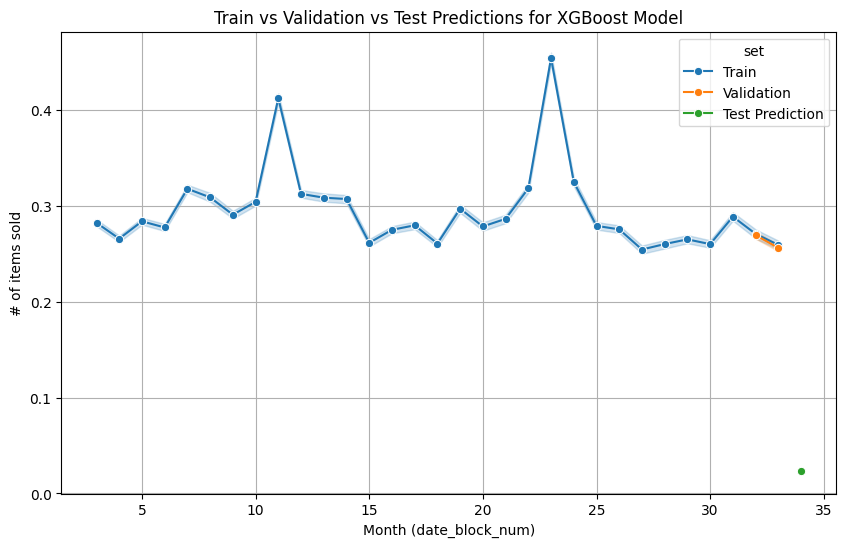

In [102]:
df_train_xgb = pd.DataFrame({
    #'date_block_num': X_train['date_block_num'],
      'date_block_num': train_all_data[train_all_data['date_block_num'] < 34]['date_block_num'],
    'item_cnt_month': train_all_data[train_all_data['date_block_num'] < 34]['monthly_sales'],
    'set': 'Train'
})

df_val_xgb = pd.DataFrame({
    'date_block_num': X_valid['date_block_num'],
    'item_cnt_month': y_pred_XGBReg,
    'set': 'Validation'
})

df_test_xgb = pd.DataFrame({
    'date_block_num': X_test['date_block_num'],
    'item_cnt_month': y_pred_test_XGBReg,
    'set': 'Test Prediction'
})

df_all_xgb = pd.concat([df_train_xgb, df_val_xgb, df_test_xgb], ignore_index=True)

# Now plot in one call
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all_xgb, x='date_block_num', y='item_cnt_month', hue='set', marker = 'o')

plt.title('Train vs Validation vs Test Predictions for XGBoost Model')
plt.xlabel('Month (date_block_num)')
plt.ylabel('# of items sold')
plt.grid(True)
plt.savefig('./images/XGBReg_preds')

In [103]:
#del train_all_data
#gc.collect();


#### 3.2 LGBM Model

##### Now it's time to train the LGBM model and then test it.

In [104]:
import warnings, io, sys
from contextlib import redirect_stdout, redirect_stderr


In [105]:
lgbm = lgb.LGBMRegressor(random_state=42, metric = 'rmse', feature_fraction = 0.75,
          bagging_fraction = 0.75,
          bagging_freq = 5,
          force_col_wise = True, verbose = -1)

warnings.filterwarnings("ignore")
# Define a SilentLogger class
class SilentLogger:
    def info(self, msg):
        pass  # ignore info messages
    def warning(self, msg):
        pass  # ignore warning messages
        
lgb.register_logger(SilentLogger())

param_grid = {
    'num_leaves': [200, 250],
    'max_depth': [-1, 10],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [500, 1000],
}
grid = GridSearchCV(
    estimator=lgbm,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  
    cv=3,          
    verbose=0
)



In [106]:

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV RMSE:", -grid.best_score_)

# Evaluate on validation set
best_model_LGBM = grid.best_estimator_
y_valid_pred_LGBM = best_model_LGBM.predict(X_valid)
rmse_LGBM = root_mean_squared_error(y_valid, y_valid_pred_LGBM)
print("Validation RMSE:", rmse_LGBM)

Best parameters: {'learning_rate': 0.05, 'max_depth': -1, 'n_estimators': 1000, 'num_leaves': 250}
Best CV RMSE: 0.6872862296450584
Validation RMSE: 0.6788079996651265


In [107]:
y_test_pred_LGBM = best_model_LGBM.predict(X_test)

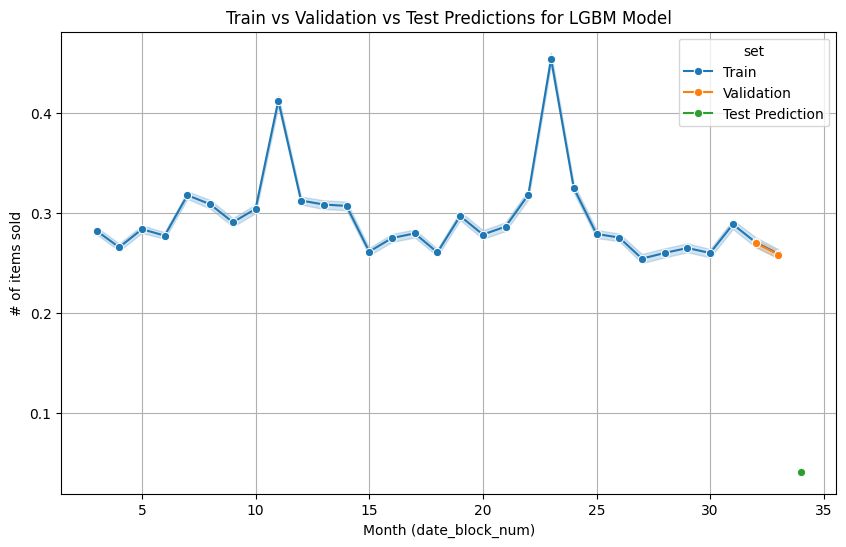

In [108]:
df_train_lgbm = pd.DataFrame({
    'date_block_num': train_all_data[train_all_data['date_block_num'] < 34]['date_block_num'],
    'item_cnt_month': train_all_data[train_all_data['date_block_num'] < 34]['monthly_sales'],
    'set': 'Train'
})

df_val_lgbm = pd.DataFrame({
    'date_block_num': X_valid['date_block_num'],
    'item_cnt_month': y_valid_pred_LGBM,
    'set': 'Validation'
})

df_test_lgbm = pd.DataFrame({
    'date_block_num': X_test['date_block_num'],
    'item_cnt_month': y_test_pred_LGBM,
    'set': 'Test Prediction'
})

df_all_lgbm = pd.concat([df_train_lgbm, df_val_lgbm, df_test_lgbm], ignore_index=True)

# Now plot in one call
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_all_lgbm, x='date_block_num', y='item_cnt_month', hue='set', marker = 'o')

plt.title('Train vs Validation vs Test Predictions for LGBM Model')
plt.xlabel('Month (date_block_num)')
plt.ylabel('# of items sold')
plt.grid(True)
plt.savefig('./images/LGBM_preds')

In [109]:
rmse_ARIMA = result_df['rmse']
rmse_ARIMA = float(rmse_ARIMA.mean())


In [111]:
rmses_df = pd.DataFrame({
    'Model': ['ARIMA', 'LGBM', 'XGB', 'Polynomial'],
    'RMSE': [rmse_ARIMA, rmse_LGBM, rmse_XGBReg, test_rmse]
})

In [112]:
rmses_df

,Model,RMSE
0,ARIMA,0.705187
1,LGBM,0.678808
2,XGB,0.687493
3,Polynomial,13.809586


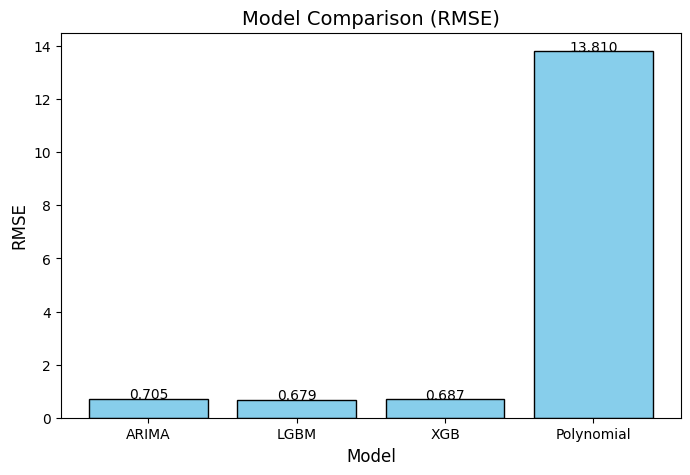

In [113]:
plt.figure(figsize=(8, 5))
plt.bar(rmses_df['Model'], rmses_df['RMSE'], color='skyblue', edgecolor='black')

# Add titles and labels
plt.title('Model Comparison (RMSE)', fontsize=14)
plt.ylabel('RMSE', fontsize=12)
plt.xlabel('Model', fontsize=12)

# Show values on top of bars
for i, v in enumerate(rmses_df['RMSE']):
    plt.text(i, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)

#plt.show()
plt.savefig('./images/RMSE_Comparison')